# Mataquito River – Quartz & Zircon Fertility Analysis

Monte Carlo error propagation using flux-ordered erosion rates and detritalPy-mix bootstrap mixing coefficients.

**Sample convention:**
- CT-5 and CT-8 are always **sample A** (numerator)
- CT-6 and CT-3 are always **sample B** (denominator)
- All ratios reported as **Qa/Qb** and **ZA/ZB**

**Erosion rate uncertainty:** External uncertainty used throughout (includes production rate uncertainty).

**Sections:**
1. Imports
2. Load sample data
3. Monte Carlo erosion rate samples
4. Flux ordering
5. Flux-ordered erosion rate summary
6. Fertility functions
7. Load zircon mixing coefficients
8. Quartz fertility
9. Zircon fertility
10. Distribution plots (individual + combined)
11. Violin plots (log10 + linear)
12. Results summary

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv, os

os.makedirs('Figures', exist_ok=True)

N = 100_000  # Number of Monte Carlo samples for erosion rate distributions

## 2. Load sample data

In [2]:
# Load sample data from Excel file
# Row index: CT-1=0, CT-2=1, CT-3=2, CT-4=3, CT-5=4, CT-6=5,
#            CT-7=6, CT-8=7, CT-9=8, CT-10=9, CT-11=10
df = pd.read_excel('/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx')

print(df[['Sample_ID','Source_Area','Erosion_rate',
          'Erosion_rate_uncertainty_internal',
          'Erosion_rate_uncertainty_external',
          'Surface_Production_Rate']])

# Build lookup dictionaries for source area and production rate by sample ID
A = df.set_index('Sample_ID')['Source_Area'].to_dict()           # km²
P = df.set_index('Sample_ID')['Surface_Production_Rate'].to_dict()  # at/g/yr

   Sample_ID  Source_Area  Erosion_rate  Erosion_rate_uncertainty_internal  \
0       CT-1     1385.185          22.9                              0.281   
1       CT-2     5760.128          94.8                              1.810   
2       CT-3      189.205          29.5                              0.556   
3       CT-4     4706.717          29.6                              0.594   
4       CT-5     1495.897         387.0                              9.230   
5       CT-6     2573.245          29.8                              0.566   
6       CT-7     1207.810         532.0                             30.600   
7       CT-8     4950.395         263.0                              9.650   
8       CT-9     6189.716         105.0                              2.010   
9      CT-10     4864.942         246.0                              8.660   
10     CT-11     4913.334         286.0                              9.560   

    Erosion_rate_uncertainty_external  Surface_Production_Rate 

## 3. Monte Carlo erosion rate samples

Erosion rates are normally distributed with mean = measured rate and sigma = external uncertainty.
External uncertainty includes production rate uncertainty and is the more conservative estimate.

In [3]:
np.random.seed(17)

# Generate N random erosion rate samples for each sample using external uncertainty
ER_ext = {}
for i, row in df.iterrows():
    sid = row['Sample_ID']
    ER_ext[sid] = np.random.normal(
        row['Erosion_rate'],                      # mean: measured erosion rate (m/Myr)
        row['Erosion_rate_uncertainty_external'],  # sigma: external uncertainty
        N
    )

print(f"{'Sample':<8} {'Median (m/Myr)':>15} {'Std':>8}")
print("-"*35)
for sid in df['Sample_ID']:
    print(f"{sid:<8} {np.median(ER_ext[sid]):>15.2f} {np.std(ER_ext[sid]):>8.2f}")

Sample    Median (m/Myr)      Std
-----------------------------------
CT-1               22.90     1.86
CT-2               94.83     7.72
CT-3               29.50     2.41
CT-4               29.61     2.44
CT-5              387.02    31.89
CT-6               29.80     2.44
CT-7              532.06    51.92
CT-8              262.93    22.85
CT-9              105.00     8.56
CT-10             245.84    21.31
CT-11             286.06    24.57


## 4. Flux ordering

Physical constraint: downstream sediment flux (E × A) must be ≥ upstream flux.
Samples that violate this are discarded, then the filtered distributions are
resampled with replacement back to N for downstream use.

**Ordering chain:**
- CT-7 → CT-5 (CT-5 must have more flux than CT-7)
- CT-1 → CT-6 (CT-6 must have more flux than CT-1)
- CT-5 + CT-6 → CT-10 / CT-11 / CT-8 (combined upstream flux ≤ child flux)
- CT-4 → CT-8 (CT-8 must have more flux than CT-4, for CT-8 parent scenarios)
- CT-3 is hydrologically independent — no flux ordering applied

In [4]:
np.random.seed(17)

# ── CT-7 → CT-5 ──────────────────────────────────────────────────────────────
# Keep samples where CT-5 flux > CT-7 flux (CT-5 drains CT-7)
m_75 = np.where(ER_ext['CT-5'] * A['CT-5'] > ER_ext['CT-7'] * A['CT-7'])[0]
CT5_ord = ER_ext['CT-5'][m_75]
print(f"CT-7→CT-5:        {len(m_75):>6}/{N} ({100*len(m_75)/N:.1f}%) retained")

# ── CT-1 → CT-6 ──────────────────────────────────────────────────────────────
# Keep samples where CT-6 flux > CT-1 flux (CT-6 drains CT-1)
m_16 = np.where(ER_ext['CT-6'] * A['CT-6'] > ER_ext['CT-1'] * A['CT-1'])[0]
CT6_ord = ER_ext['CT-6'][m_16]
print(f"CT-1→CT-6:        {len(m_16):>6}/{N} ({100*len(m_16)/N:.1f}%) retained")

# Resample ordered CT-5 and CT-6 back to N with replacement
CT5_res = np.random.choice(CT5_ord, size=N, replace=True)
CT6_res = np.random.choice(CT6_ord, size=N, replace=True)

# ── CT-5 + CT-6 → CT-10 ──────────────────────────────────────────────────────
# CT-10 must have more flux than combined CT-5 + CT-6
m_10 = np.where(ER_ext['CT-10'] * A['CT-10'] >= CT5_res * A['CT-5'] + CT6_res * A['CT-6'])[0]
CT5_10 = CT5_res[m_10]; CT6_10 = CT6_res[m_10]; CT10_f = ER_ext['CT-10'][m_10]
print(f"CT-5+CT-6→CT-10:  {len(m_10):>6}/{N} ({100*len(m_10)/N:.1f}%) retained")

# ── CT-5 + CT-6 → CT-11 ──────────────────────────────────────────────────────
m_11 = np.where(ER_ext['CT-11'] * A['CT-11'] >= CT5_res * A['CT-5'] + CT6_res * A['CT-6'])[0]
CT5_11 = CT5_res[m_11]; CT6_11 = CT6_res[m_11]; CT11_f = ER_ext['CT-11'][m_11]
print(f"CT-5+CT-6→CT-11:  {len(m_11):>6}/{N} ({100*len(m_11)/N:.1f}%) retained")

# ── CT-5 + CT-6 → CT-8 ───────────────────────────────────────────────────────
m_8 = np.where(ER_ext['CT-8'] * A['CT-8'] >= CT5_res * A['CT-5'] + CT6_res * A['CT-6'])[0]
CT5_8 = CT5_res[m_8]; CT6_8 = CT6_res[m_8]; CT8_f = ER_ext['CT-8'][m_8]
print(f"CT-5+CT-6→CT-8:   {len(m_8):>6}/{N} ({100*len(m_8)/N:.1f}%) retained")

# ── CT-4 → CT-8 (for CT-8 as parent) ────────────────────────────────────────
# CT-8 must have more flux than CT-4
m_48 = np.where(ER_ext['CT-8'] * A['CT-8'] > ER_ext['CT-4'] * A['CT-4'])[0]
CT8_res = np.random.choice(ER_ext['CT-8'][m_48], size=N, replace=True)
print(f"CT-4→CT-8:        {len(m_48):>6}/{N} ({100*len(m_48)/N:.1f}%) retained")

# ── CT-3, CT-4, CT-10, CT-11 resampled independently ─────────────────────────
CT3_res  = np.random.choice(ER_ext['CT-3'],  size=N, replace=True)
CT4_res  = np.random.choice(ER_ext['CT-4'],  size=N, replace=True)
CT10_res = np.random.choice(CT10_f,          size=N, replace=True)
CT11_res = np.random.choice(CT11_f,          size=N, replace=True)

CT-7→CT-5:         20997/100000 (21.0%) retained
CT-1→CT-6:        100000/100000 (100.0%) retained
CT-5+CT-6→CT-10:  100000/100000 (100.0%) retained
CT-5+CT-6→CT-11:  100000/100000 (100.0%) retained
CT-5+CT-6→CT-8:   100000/100000 (100.0%) retained
CT-4→CT-8:        100000/100000 (100.0%) retained


## 5. Flux-ordered erosion rate summary

In [5]:
print(f"{'Array':<32} {'Median (m/Myr)':>15} {'Std':>8}")
print("-"*58)
for label, arr in [
    ('CT-5 (ordered vs CT-7)',     CT5_res),
    ('CT-6 (ordered vs CT-1)',     CT6_res),
    ('CT-5 | CT-10 scenario',      CT5_10),
    ('CT-6 | CT-10 scenario',      CT6_10),
    ('CT-10',                      CT10_f),
    ('CT-5 | CT-11 scenario',      CT5_11),
    ('CT-6 | CT-11 scenario',      CT6_11),
    ('CT-11',                      CT11_f),
    ('CT-5 | CT-8 scenario',       CT5_8),
    ('CT-6 | CT-8 scenario',       CT6_8),
    ('CT-8 (via CT-5+CT-6)',       CT8_f),
    ('CT-8 (ordered vs CT-4)',     CT8_res),
    ('CT-3 (independent)',         CT3_res),
]:
    print(f"{label:<32} {np.median(arr):>15.2f} {np.std(arr):>8.2f}")

Array                             Median (m/Myr)      Std
----------------------------------------------------------
CT-5 (ordered vs CT-7)                    413.27    27.18
CT-6 (ordered vs CT-1)                     29.79     2.43
CT-5 | CT-10 scenario                     413.27    27.18
CT-6 | CT-10 scenario                      29.79     2.43
CT-10                                     245.84    21.31
CT-5 | CT-11 scenario                     413.27    27.18
CT-6 | CT-11 scenario                      29.79     2.43
CT-11                                     286.06    24.57
CT-5 | CT-8 scenario                      413.27    27.18
CT-6 | CT-8 scenario                       29.79     2.43
CT-8 (via CT-5+CT-6)                      262.93    22.85
CT-8 (ordered vs CT-4)                    262.91    22.87
CT-3 (independent)                         29.50     2.41


## 6. Fertility functions

In [6]:
THRESHOLD = 0.01  # Filter mixing coefficients below 1% or above 99%

def load_wct(csv_path):
    """
    Load two-column detritalPy-mix bootstrap coefficient CSV.
    Filters rows where either coefficient is outside (0.01, 0.99) to avoid
    near-zero denominator instability in ratio calculations.
    
    Returns: wa (array), wb (array), n_total (int), n_kept (int)
    """
    wa, wb = [], []
    n = 0
    with open(csv_path) as f:
        reader = csv.reader(f)
        next(reader)  # skip header
        for row in reader:
            n += 1
            a, b = float(row[0]), float(row[1])
            # Keep only rows where both coefficients are in (0.01, 0.99)
            if a > THRESHOLD and a < (1 - THRESHOLD) and b > THRESHOLD and b < (1 - THRESHOLD):
                wa.append(a)
                wb.append(b)
    return np.array(wa), np.array(wb), n, len(wa)


def quartz_fertility(E_a, E_b, E_c, A_a, A_b, A_c, P_a, P_b, P_c):
    """
    Compute quartz fertility ratio Qa/Qb from the mixing equation.
    
    Equation: Qb/Qa = (Pc*Ea*Aa - Pa*Ec*Aa) / (Pb*Ec*Ab - Pc*Eb*Ab)
    Qa/Qb is returned as the inverse.
    
    E_a, E_b, E_c: erosion rate sample arrays (m/Myr)
    A_a, A_b, A_c: source areas (km²) — scalars
    P_a, P_b, P_c: spallation production rates (at/g/yr) — scalars
    
    Returns: Qa_Qb array (positive values only), boolean mask
    """
    num = P_c * E_a * A_a - P_a * E_c * A_a  # numerator of Qb/Qa
    den = P_b * E_c * A_b - P_c * E_b * A_b  # denominator of Qb/Qa
    Qb_Qa = num / den
    mask = Qb_Qa > 0  # retain only physically meaningful (positive) values
    return (1 / Qb_Qa[mask]), mask  # return Qa/Qb


def zircon_fertility(wa, wb, ER_A, ER_B, A_A, A_B, num_samples=10000, seed=17):
    """
    Compute zircon fertility ratio ZA/ZB using Equation 11.
    
    Equation: ZA/ZB = (wct_a/wct_b) * (ER_B * A_B) / (ER_A * A_A)
    
    wct rows are sampled by index to keep wct_a and wct_b coupled (sum = 1).
    Erosion rate samples are taken as the first num_samples elements of
    the flux-ordered arrays passed in.
    
    wa, wb: coupled bootstrap mixing coefficient arrays from detritalPy-mix
    ER_A, ER_B: flux-ordered erosion rate arrays (m/Myr)
    A_A, A_B: source areas (km²) — scalars
    num_samples: number of Monte Carlo draws
    seed: random seed
    
    Returns: dict with ZA_ZB and ZB_ZA entries, each containing
             samples, median, p25, p75, and log10 equivalents
    """
    np.random.seed(seed)
    
    # Sample row indices to keep wct_a and wct_b coupled (preserves wct_a + wct_b = 1)
    idx = np.random.choice(len(wa), size=num_samples, replace=True)
    ratio = wa[idx] / wb[idx]  # wct_a / wct_b for each sampled row
    
    # Take first num_samples from flux-ordered erosion rate arrays
    ER_A_s = ER_A[:num_samples]
    ER_B_s = ER_B[:num_samples]
    
    # Eq. 11: ZA/ZB = (wct_a/wct_b) * (ER_B * A_B) / (ER_A * A_A)
    ZA_ZB = ratio * (ER_B_s * A_B) / (ER_A_s * A_A)
    
    def stats(x):
        """Compute summary statistics for a distribution."""
        return {
            'samples':      x,
            'median':       np.median(x),
            'p25':          np.percentile(x, 25),
            'p75':          np.percentile(x, 75),
            'log10_samples': np.log10(x),
            'log10_median': np.median(np.log10(x)),
            'log10_p25':    np.percentile(np.log10(x), 25),
            'log10_p75':    np.percentile(np.log10(x), 75),
        }
    
    return {'ZA_ZB': stats(ZA_ZB), 'ZB_ZA': stats(1 / ZA_ZB)}

print("Functions loaded.")

Functions loaded.


## 7. Load zircon mixing coefficients

In [7]:
BASE = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/'

# Map scenario keys to CSV filenames
csv_paths = {
    'ct4':    'mix_coeffs_all_ct-5_ct-6_to_ct-4.csv',
    'ct10':   'mix_coeffs_all_ct-5_ct-6_to_ct-10.csv',
    'ct11':   'mix_coeffs_all_ct-5_ct-6_to_ct-11.csv',
    'ct82':   'mix_coeffs_all_ct-5_ct-6_to_ct-8.2.csv',
    'ct9_83': 'mix_coeffs_all_ct-8.2_ct-3_to_ct-9.csv',
    'ct2_83': 'mix_coeffs_all_ct-8.2_ct-3_to_ct-2.csv',
    'ct9_43': 'mix_coeffs_all_ct-4_ct-3_to_ct-9.csv',
    'ct9_103':'mix_coeffs_all_ct-10_ct-3_to_ct-9.csv',
    'ct9_113':'mix_coeffs_all_ct-11_ct-3_to_ct-9.csv',
}

# Load and filter all CSVs, print retention summary
wct = {}
print(f"{'Key':<12} {'Kept':>6} {'Total':>7} {'% kept':>7} {'Med wct_a':>10} {'Med wct_b':>10}")
print("-"*55)
for key, fname in csv_paths.items():
    wa, wb, nt, nk = load_wct(BASE + fname)
    wct[key] = (wa, wb)
    print(f"{key:<12} {nk:>6} {nt:>7} {100*nk/nt:>6.1f}% {np.median(wa):>10.4f} {np.median(wb):>10.4f}")

Key            Kept   Total  % kept  Med wct_a  Med wct_b
-------------------------------------------------------
ct4            9886   10000   98.9%     0.2675     0.7325
ct10           9999   10000  100.0%     0.6398     0.3602
ct11           9991   10000   99.9%     0.4618     0.5382
ct82          10000   10000  100.0%     0.5225     0.4775
ct9_83         9983   10000   99.8%     0.8666     0.1334
ct2_83         9998   10000  100.0%     0.8260     0.1740
ct9_43         8821   10000   88.2%     0.9365     0.0635
ct9_103        9998   10000  100.0%     0.8683     0.1317
ct9_113        9994   10000   99.9%     0.8876     0.1124


## 8. Quartz fertility (Qa/Qb)

**a = CT-5 or CT-8 (numerator), b = CT-6 or CT-3 (denominator)**

Adjusted CT-3 source areas used for CT-8/CT-3 scenarios:
- CT-9: A_CT3 = A(CT-9) − A(CT-8)  — CT-3 represents unsampled coastal area upstream of CT-9
- CT-2: A_CT3 = A(CT-2) − A(CT-8)  — same logic for CT-2

In [8]:
# Adjusted CT-3 source areas — CT-3 represents the unsampled coastal cordillera
# contributing area between CT-8 and the child sample
A_CT3_9 = A['CT-9'] - A['CT-8']  # km²
A_CT3_2 = A['CT-2'] - A['CT-8']  # km²

# CT-5(a) + CT-6(b) scenarios
# CT-4: no flux ordering applied — CT-4 erosion rate is similar to CT-6, constraint is unstable
Q_ct4,  _ = quartz_fertility(ER_ext['CT-5'], ER_ext['CT-6'], ER_ext['CT-4'],
                               A['CT-5'], A['CT-6'], A['CT-4'],
                               P['CT-5'], P['CT-6'], P['CT-4'])

Q_ct10, _ = quartz_fertility(CT5_10, CT6_10, CT10_f,
                               A['CT-5'], A['CT-6'], A['CT-10'],
                               P['CT-5'], P['CT-6'], P['CT-10'])

Q_ct11, _ = quartz_fertility(CT5_11, CT6_11, CT11_f,
                               A['CT-5'], A['CT-6'], A['CT-11'],
                               P['CT-5'], P['CT-6'], P['CT-11'])

Q_ct82, _ = quartz_fertility(CT5_8, CT6_8, CT8_f,
                               A['CT-5'], A['CT-6'], A['CT-8'],
                               P['CT-5'], P['CT-6'], P['CT-8'])

# CT-8(a) + CT-3(b) scenarios — use adjusted CT-3 areas
Q_ct9,  _ = quartz_fertility(CT8_res, CT3_res, ER_ext['CT-9'],
                               A['CT-8'], A_CT3_9, A['CT-9'],
                               P['CT-8'], P['CT-3'], P['CT-9'])

Q_ct2,  _ = quartz_fertility(CT8_res, CT3_res, ER_ext['CT-2'],
                               A['CT-8'], A_CT3_2, A['CT-2'],
                               P['CT-8'], P['CT-3'], P['CT-2'])

# Print results
print("Quartz Fertility Qa/Qb (external uncertainty)")
print(f"{'Scenario':<25} {'Median':>8} {'25th':>8} {'75th':>8} {'n retained':>12}")
print("-"*65)
qtz_results = [
    ('CT-5/CT-6 → CT-4',   Q_ct4),
    ('CT-5/CT-6 → CT-10',  Q_ct10),
    ('CT-5/CT-6 → CT-11',  Q_ct11),
    ('CT-5/CT-6 → CT-8.2', Q_ct82),
    ('CT-8/CT-3 → CT-9',   Q_ct9),
    ('CT-8/CT-3 → CT-2',   Q_ct2),
]
for label, Q in qtz_results:
    q25, q50, q75 = np.percentile(Q, [25, 50, 75])
    print(f"{label:<25} {q50:>8.4f} {q25:>8.4f} {q75:>8.4f} {len(Q):>12}")

Quartz Fertility Qa/Qb (external uncertainty)
Scenario                    Median     25th     75th   n retained
-----------------------------------------------------------------
CT-5/CT-6 → CT-4            0.0127   0.0062   0.0214        55523
CT-5/CT-6 → CT-10           3.4996   2.6781   4.8205        99781
CT-5/CT-6 → CT-11           7.4759   4.9496  13.1414        90945
CT-5/CT-6 → CT-8.2          4.8322   3.4883   7.3302        98287
CT-8/CT-3 → CT-9            0.0295   0.0227   0.0375        99985
CT-8/CT-3 → CT-2            0.0110   0.0079   0.0146        99531


## 9. Zircon fertility (ZA/ZB)

**a = CT-5 or CT-8 or CT-4/CT-10/CT-11 (numerator), b = CT-6 or CT-3 (denominator)**

Same adjusted CT-3 areas used as in quartz section.

In [9]:
M = 10000  # Number of samples for zircon fertility Monte Carlo

# CT-5(a) + CT-6(b) scenarios
# CT-4: uses unordered erosion rate samples (same reason as quartz)
zr_ct4   = zircon_fertility(*wct['ct4'],  ER_ext['CT-5'][:M], ER_ext['CT-6'][:M], A['CT-5'], A['CT-6'], M)
zr_ct10  = zircon_fertility(*wct['ct10'], CT5_10[:M],          CT6_10[:M],          A['CT-5'], A['CT-6'], M)
zr_ct11  = zircon_fertility(*wct['ct11'], CT5_11[:M],          CT6_11[:M],          A['CT-5'], A['CT-6'], M)
zr_ct82  = zircon_fertility(*wct['ct82'], CT5_8[:M],           CT6_8[:M],           A['CT-5'], A['CT-6'], M)

# CT-8(a) + CT-3(b) → CT-9 and CT-2 — use adjusted CT-3 areas
zr_ct9_83  = zircon_fertility(*wct['ct9_83'], CT8_res[:M], CT3_res[:M], A['CT-8'], A_CT3_9, M)
zr_ct2_83  = zircon_fertility(*wct['ct2_83'], CT8_res[:M], CT3_res[:M], A['CT-8'], A_CT3_2, M)

# CT-4(a) + CT-3(b) → CT-9 — raw CT-3 area (CT-4 is itself a local basin)
zr_ct9_43  = zircon_fertility(*wct['ct9_43'],  CT4_res[:M],  CT3_res[:M], A['CT-4'],  A['CT-3'], M)

# CT-10(a) + CT-3(b) → CT-9
zr_ct9_103 = zircon_fertility(*wct['ct9_103'], CT10_res[:M], CT3_res[:M], A['CT-10'], A['CT-3'], M)

# CT-11(a) + CT-3(b) → CT-9
zr_ct9_113 = zircon_fertility(*wct['ct9_113'], CT11_res[:M], CT3_res[:M], A['CT-11'], A['CT-3'], M)

# Print results
print("Zircon Fertility ZA/ZB (external uncertainty)")
print(f"{'Scenario':<30} {'Median':>8} {'25th':>8} {'75th':>8} {'log10 med':>10} {'log10 IQR':>18}")
print("-"*85)
zrc_results = [
    ('ZCT-5/ZCT-6 → CT-4',    zr_ct4),
    ('ZCT-5/ZCT-6 → CT-10',   zr_ct10),
    ('ZCT-5/ZCT-6 → CT-11',   zr_ct11),
    ('ZCT-5/ZCT-6 → CT-8.2',  zr_ct82),
    ('ZCT-8/ZCT-3 → CT-9',    zr_ct9_83),
    ('ZCT-8/ZCT-3 → CT-2',    zr_ct2_83),
    ('ZCT-4/ZCT-3 → CT-9',    zr_ct9_43),
    ('ZCT-10/ZCT-3 → CT-9',   zr_ct9_103),
    ('ZCT-11/ZCT-3 → CT-9',   zr_ct9_113),
]
for label, zr in zrc_results:
    r = zr['ZA_ZB']
    print(f"{label:<30} {r['median']:>8.3f} {r['p25']:>8.3f} {r['p75']:>8.3f} {r['log10_median']:>10.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

Zircon Fertility ZA/ZB (external uncertainty)
Scenario                         Median     25th     75th  log10 med          log10 IQR
-------------------------------------------------------------------------------------
ZCT-5/ZCT-6 → CT-4                0.049    0.035    0.065    -1.3126 (-1.4620 - -1.1868)
ZCT-5/ZCT-6 → CT-10               0.218    0.142    0.318    -0.6619 (-0.8485 - -0.4977)
ZCT-5/ZCT-6 → CT-11               0.105    0.062    0.159    -0.9809 (-1.2090 - -0.7973)
ZCT-5/ZCT-6 → CT-8.2              0.135    0.092    0.192    -0.8682 (-1.0382 - -0.7171)
ZCT-8/ZCT-3 → CT-9                0.185    0.128    0.282    -0.7340 (-0.8914 - -0.5504)
ZCT-8/ZCT-3 → CT-2                0.088    0.073    0.110    -1.0540 (-1.1369 - -0.9578)
ZCT-4/ZCT-3 → CT-9                0.589    0.450    0.764    -0.2296 (-0.3467 - -0.1168)
ZCT-10/ZCT-3 → CT-9               0.031    0.022    0.046    -1.5095 (-1.6660 - -1.3376)
ZCT-11/ZCT-3 → CT-9               0.031    0.021    0.047    -1.5042

## 10. Distribution plots

Individual 4-panel plots (quartz linear, quartz log10, zircon linear, zircon log10) for each scenario, then combined comparison plots at the end.

In [10]:
def plot_single_scenario(Q, zr, label, save_path=None):
    """
    4-panel distribution plot for a single scenario.
    Panels: quartz linear, quartz log10, zircon linear, zircon log10.
    Q: quartz Qa/Qb array
    zr: zircon results dict from zircon_fertility()
    label: scenario name for title
    """
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    fig.suptitle(label, fontsize=12, fontweight='bold')
    
    Z = zr['ZA_ZB']['samples']
    
    # Quartz — linear
    axes[0].hist(Q, bins=100, color='steelblue', alpha=0.8, density=True, edgecolor='none')
    axes[0].axvline(np.median(Q), color='black', linewidth=1.2, linestyle='--', label=f'Median: {np.median(Q):.2f}')
    axes[0].set_xlabel('Qa/Qb'); axes[0].set_title('Quartz (linear)')
    axes[0].legend(fontsize=8)
    
    # Quartz — log10
    logQ = np.log10(Q)
    axes[1].hist(logQ, bins=100, color='steelblue', alpha=0.8, density=True, edgecolor='none')
    axes[1].axvline(np.median(logQ), color='black', linewidth=1.2, linestyle='--', label=f'Median: {np.median(logQ):.2f}')
    axes[1].axvline(0, color='gray', linewidth=0.8, linestyle=':')  # ratio = 1 line
    axes[1].set_xlabel('log10(Qa/Qb)'); axes[1].set_title('Quartz (log10)')
    axes[1].legend(fontsize=8)
    
    # Zircon — linear
    axes[2].hist(Z, bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    axes[2].axvline(np.median(Z), color='black', linewidth=1.2, linestyle='--', label=f'Median: {np.median(Z):.2f}')
    axes[2].set_xlabel('ZA/ZB'); axes[2].set_title('Zircon (linear)')
    axes[2].legend(fontsize=8)
    
    # Zircon — log10
    logZ = zr['ZA_ZB']['log10_samples']
    axes[3].hist(logZ, bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    axes[3].axvline(np.median(logZ), color='black', linewidth=1.2, linestyle='--', label=f'Median: {np.median(logZ):.2f}')
    axes[3].axvline(0, color='gray', linewidth=0.8, linestyle=':')  # ratio = 1 line
    axes[3].set_xlabel('log10(ZA/ZB)'); axes[3].set_title('Zircon (log10)')
    axes[3].legend(fontsize=8)
    
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

print("Plotting individual scenario distributions...")

Plotting individual scenario distributions...


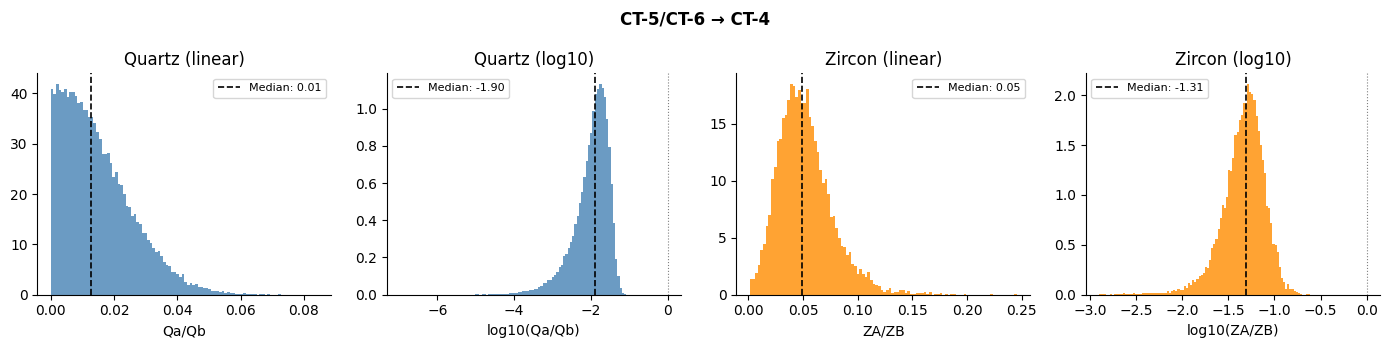

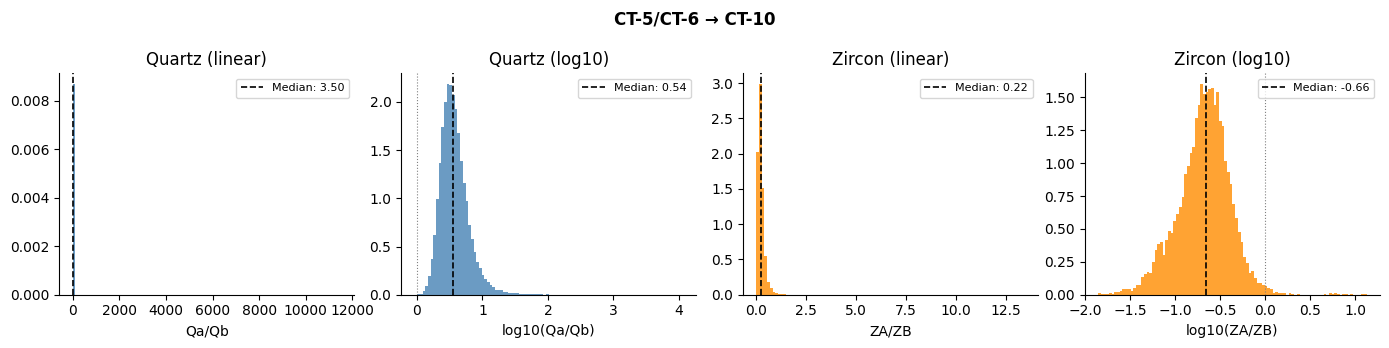

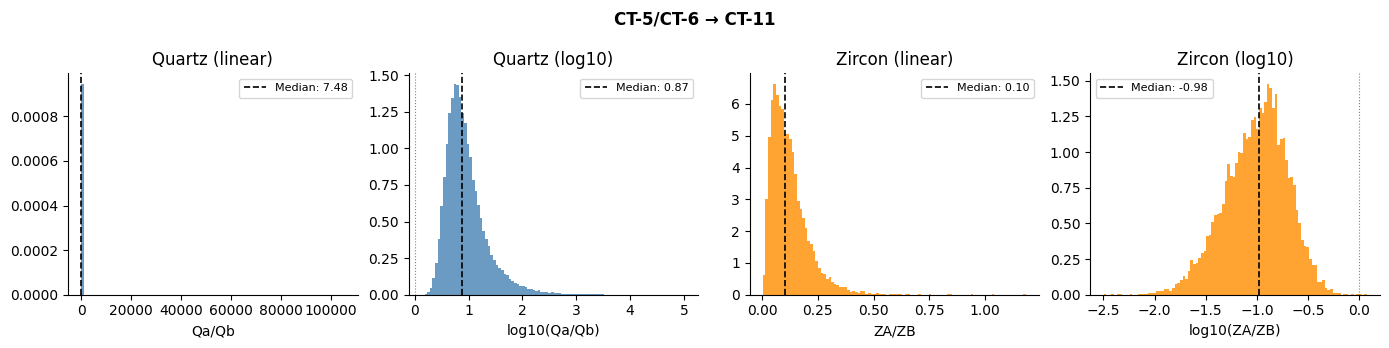

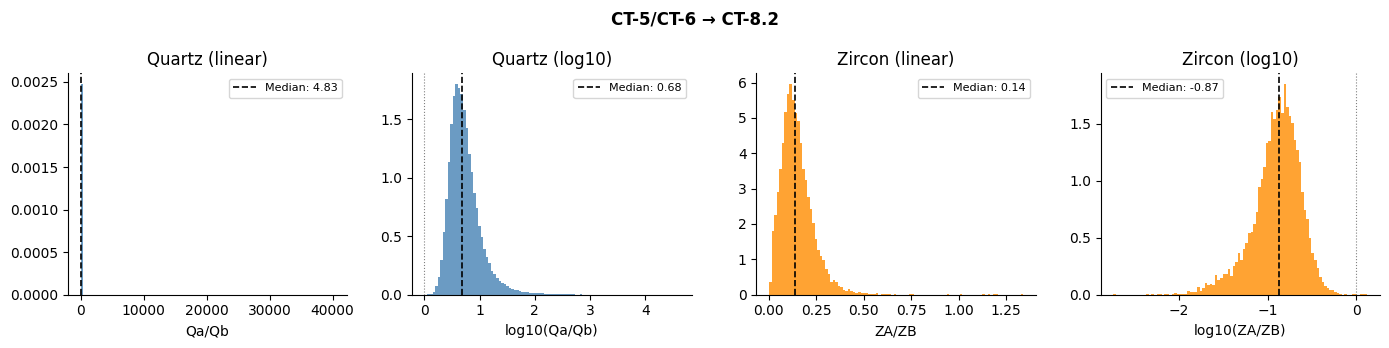

In [11]:
# Individual plots for CT-5/CT-6 parent scenarios
individual_56 = [
    (Q_ct4,  zr_ct4,  'CT-5/CT-6 → CT-4',   'Figures/dist_ct4.png'),
    (Q_ct10, zr_ct10, 'CT-5/CT-6 → CT-10',  'Figures/dist_ct10.png'),
    (Q_ct11, zr_ct11, 'CT-5/CT-6 → CT-11',  'Figures/dist_ct11.png'),
    (Q_ct82, zr_ct82, 'CT-5/CT-6 → CT-8.2', 'Figures/dist_ct82.png'),
]
for Q, zr, label, path in individual_56:
    plot_single_scenario(Q, zr, label, save_path=path)

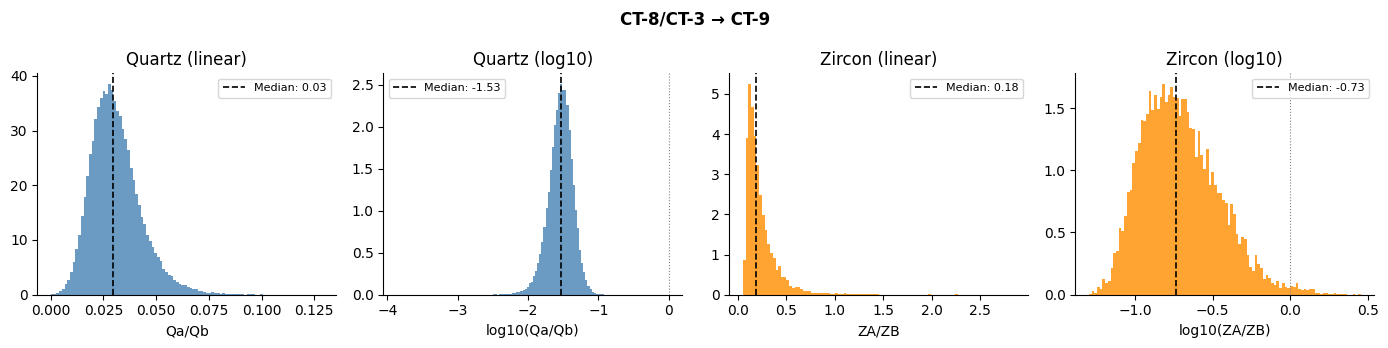

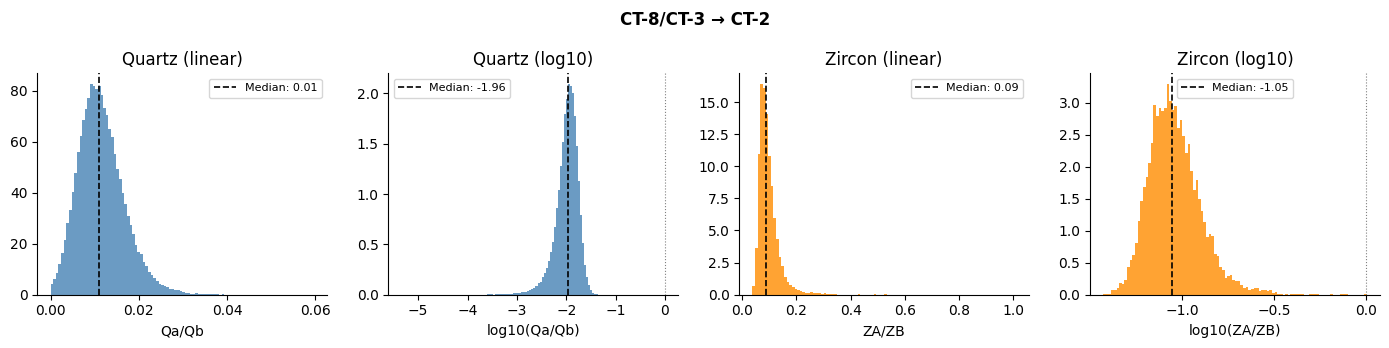

In [12]:
# Individual plots for CT-8/CT-3 parent scenarios
individual_83 = [
    (Q_ct9, zr_ct9_83, 'CT-8/CT-3 → CT-9', 'Figures/dist_ct9_83.png'),
    (Q_ct2, zr_ct2_83, 'CT-8/CT-3 → CT-2', 'Figures/dist_ct2_83.png'),
]
for Q, zr, label, path in individual_83:
    plot_single_scenario(Q, zr, label, save_path=path)

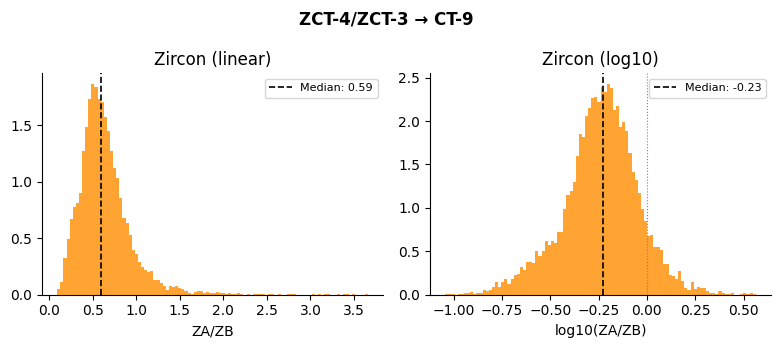

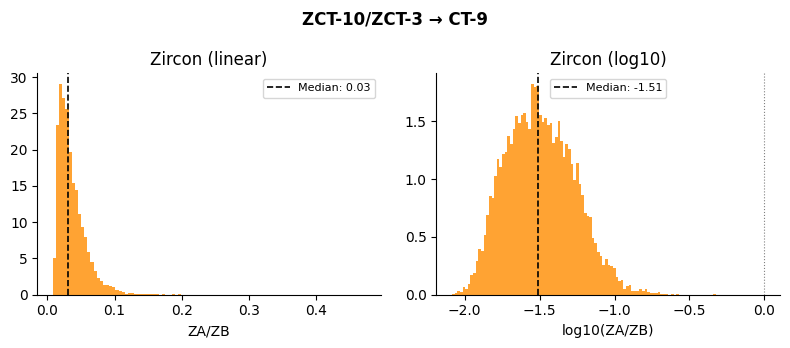

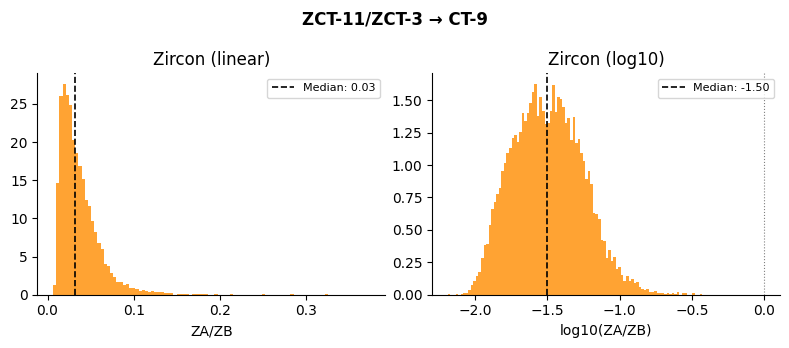

In [13]:
# Individual plots for additional zircon-only scenarios (no quartz equivalent)
# These use raw CT-3 area since CT-4/CT-10/CT-11 are themselves local basins
individual_z_only = [
    (zr_ct9_43,  'ZCT-4/ZCT-3 → CT-9',   'Figures/dist_z_ct9_43.png'),
    (zr_ct9_103, 'ZCT-10/ZCT-3 → CT-9',  'Figures/dist_z_ct9_103.png'),
    (zr_ct9_113, 'ZCT-11/ZCT-3 → CT-9',  'Figures/dist_z_ct9_113.png'),
]

for zr, label, path in individual_z_only:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
    fig.suptitle(label, fontsize=12, fontweight='bold')
    Z = zr['ZA_ZB']['samples']
    logZ = zr['ZA_ZB']['log10_samples']
    
    # Zircon linear
    axes[0].hist(Z, bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    axes[0].axvline(np.median(Z), color='black', linewidth=1.2, linestyle='--', label=f'Median: {np.median(Z):.2f}')
    axes[0].set_xlabel('ZA/ZB'); axes[0].set_title('Zircon (linear)')
    axes[0].legend(fontsize=8)
    
    # Zircon log10
    axes[1].hist(logZ, bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    axes[1].axvline(np.median(logZ), color='black', linewidth=1.2, linestyle='--', label=f'Median: {np.median(logZ):.2f}')
    axes[1].axvline(0, color='gray', linewidth=0.8, linestyle=':')
    axes[1].set_xlabel('log10(ZA/ZB)'); axes[1].set_title('Zircon (log10)')
    axes[1].legend(fontsize=8)
    
    for ax in axes:
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

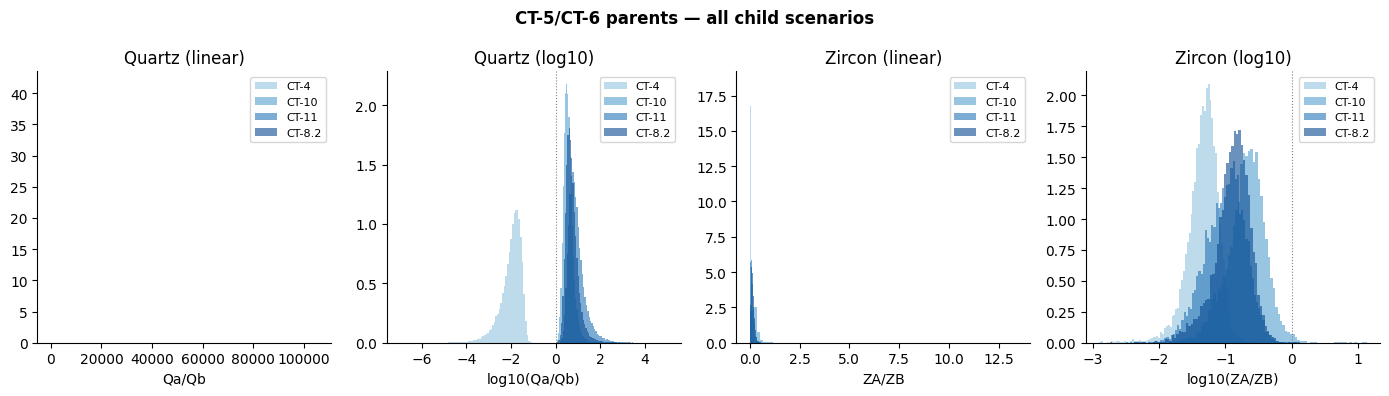

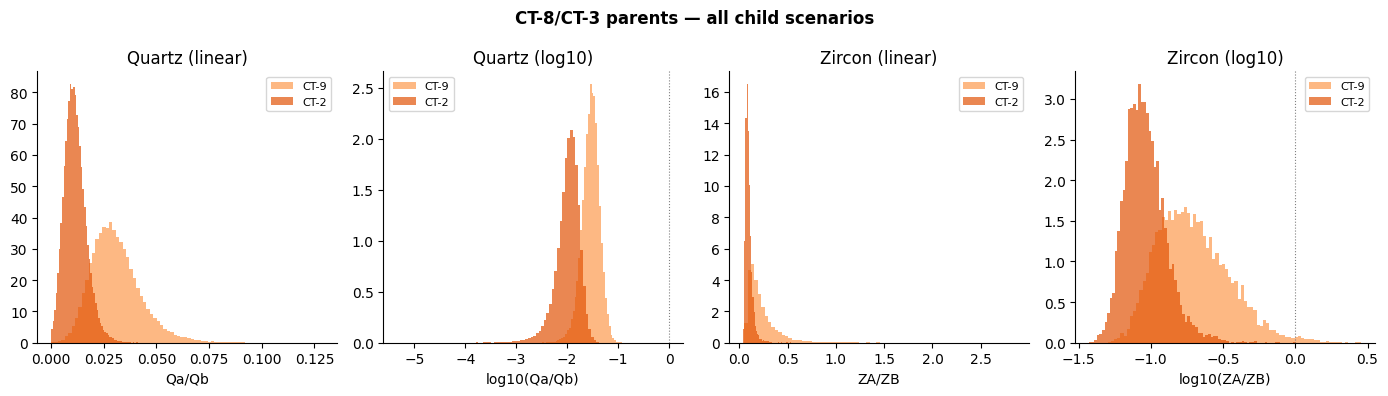

In [14]:
# ── Combined comparison plots ──────────────────────────────────────────────────
# CT-5/CT-6 group: all four child scenarios overlaid on same axes
cmap = plt.cm.Blues
labels_56 = ['CT-4','CT-10','CT-11','CT-8.2']
colors_56 = [cmap(0.4 + 0.5*i/3) for i in range(4)]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('CT-5/CT-6 parents — all child scenarios', fontsize=12, fontweight='bold')

for i, (Q, zr, lbl) in enumerate(zip([Q_ct4,Q_ct10,Q_ct11,Q_ct82],
                                       [zr_ct4,zr_ct10,zr_ct11,zr_ct82],
                                       labels_56)):
    c = colors_56[i]
    Z = zr['ZA_ZB']['samples']
    
    axes[0].hist(Q,           bins=80, alpha=0.6, color=c, density=True, label=lbl, edgecolor='none')
    axes[1].hist(np.log10(Q), bins=80, alpha=0.6, color=c, density=True, label=lbl, edgecolor='none')
    axes[2].hist(Z,           bins=80, alpha=0.6, color=c, density=True, label=lbl, edgecolor='none')
    axes[3].hist(zr['ZA_ZB']['log10_samples'], bins=80, alpha=0.6, color=c, density=True, label=lbl, edgecolor='none')

axes[0].set_xlabel('Qa/Qb');        axes[0].set_title('Quartz (linear)')
axes[1].set_xlabel('log10(Qa/Qb)'); axes[1].set_title('Quartz (log10)')
axes[2].set_xlabel('ZA/ZB');        axes[2].set_title('Zircon (linear)')
axes[3].set_xlabel('log10(ZA/ZB)'); axes[3].set_title('Zircon (log10)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle=':')
axes[3].axvline(0, color='gray', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.savefig('Figures/dist_combined_ct5_ct6.png', dpi=300, bbox_inches='tight')
plt.show()

# CT-8/CT-3 group
cmap2 = plt.cm.Oranges
labels_83 = ['CT-9','CT-2']
colors_83 = [cmap2(0.45), cmap2(0.7)]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('CT-8/CT-3 parents — all child scenarios', fontsize=12, fontweight='bold')

for i, (Q, zr, lbl) in enumerate(zip([Q_ct9, Q_ct2],
                                       [zr_ct9_83, zr_ct2_83],
                                       labels_83)):
    c = colors_83[i]
    Z = zr['ZA_ZB']['samples']
    axes[0].hist(Q,           bins=80, alpha=0.7, color=c, density=True, label=lbl, edgecolor='none')
    axes[1].hist(np.log10(Q), bins=80, alpha=0.7, color=c, density=True, label=lbl, edgecolor='none')
    axes[2].hist(Z,           bins=80, alpha=0.7, color=c, density=True, label=lbl, edgecolor='none')
    axes[3].hist(zr['ZA_ZB']['log10_samples'], bins=80, alpha=0.7, color=c, density=True, label=lbl, edgecolor='none')

axes[0].set_xlabel('Qa/Qb');        axes[0].set_title('Quartz (linear)')
axes[1].set_xlabel('log10(Qa/Qb)'); axes[1].set_title('Quartz (log10)')
axes[2].set_xlabel('ZA/ZB');        axes[2].set_title('Zircon (linear)')
axes[3].set_xlabel('log10(ZA/ZB)'); axes[3].set_title('Zircon (log10)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle=':')
axes[3].axvline(0, color='gray', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.savefig('Figures/dist_combined_ct8_ct3.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Violin plots — log10 and linear space

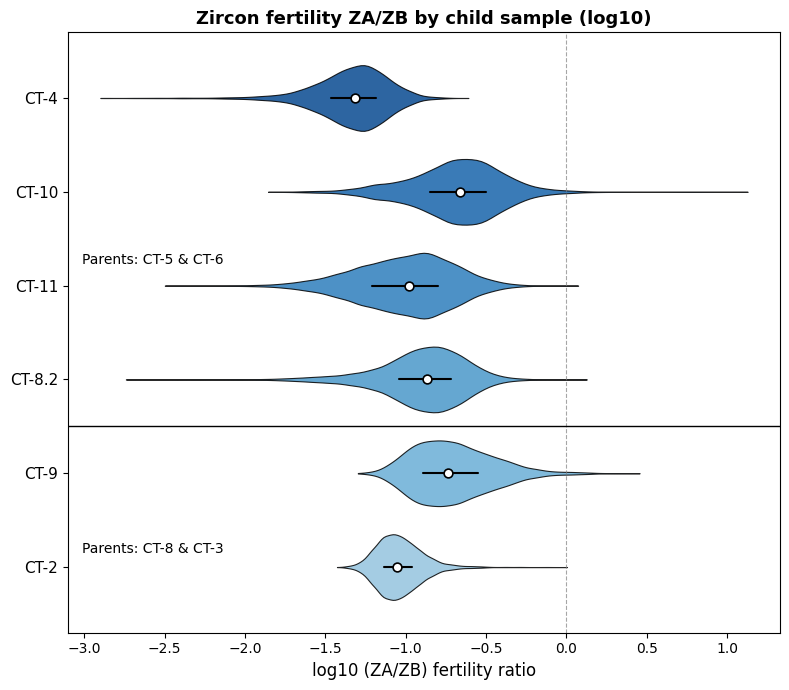

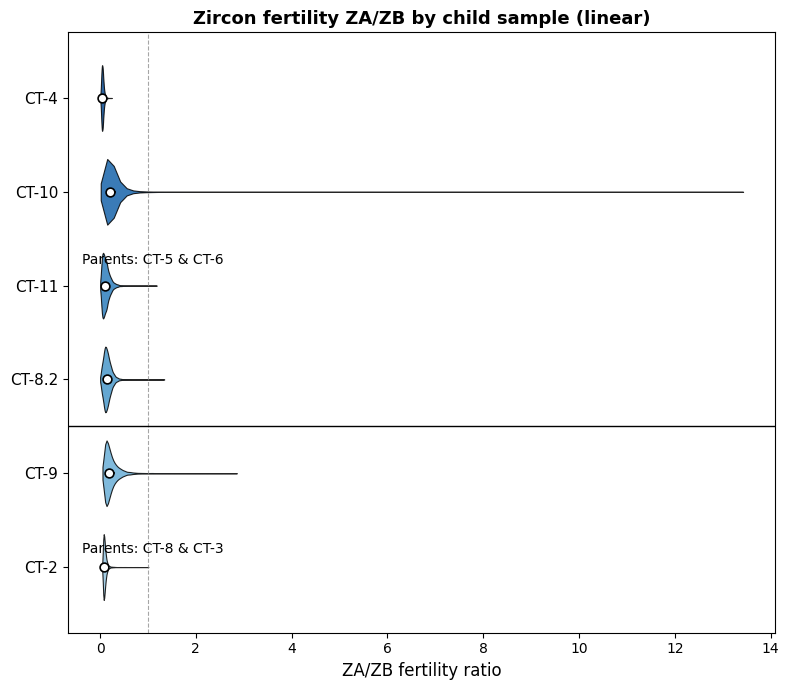

(<Figure size 800x700 with 1 Axes>,
 <Axes: title={'center': 'Zircon fertility ZA/ZB by child sample (linear)'}, xlabel='ZA/ZB fertility ratio'>)

In [15]:
def zfertility_violin(results_list, labels, title, direction='ZA_ZB',
                     use_log=True, separator_after=None, group_labels=None,
                     save_path=None, figsize=(8, 7)):
    """
    Horizontal violin plot of ZA/ZB fertility distributions.
    
    results_list: list of dicts from zircon_fertility()
    labels: y-axis labels (child sample names)
    direction: 'ZA_ZB' or 'ZB_ZA'
    use_log: if True plots log10 values, if False plots linear values
    separator_after: draw horizontal line after this position (1-based)
    group_labels: list of (text, y_axes_fraction) tuples for group annotations
    """
    # Select log10 or linear samples
    if use_log:
        data = [r[direction]['log10_samples'] for r in results_list]
        xlabel = f'log10 ({direction.replace("_","/")}) fertility ratio'
    else:
        data = [r[direction]['samples'] for r in results_list]
        xlabel = f'{direction.replace("_","/")} fertility ratio'
    
    n = len(labels)
    cmap = plt.cm.Blues
    colors = [cmap(0.4 + 0.5*i/max(n-1,1)) for i in range(n)]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    parts = ax.violinplot(data, positions=range(1, n+1), vert=False,
                          widths=0.7, showmeans=False, showextrema=False, showmedians=False)
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i]); pc.set_edgecolor('black')
        pc.set_linewidth(0.8); pc.set_alpha(0.85)
    
    # Overlay IQR bar and median dot for each violin
    for i, (d, pos) in enumerate(zip(data, range(1, n+1))):
        ax.plot([np.percentile(d,25), np.percentile(d,75)], [pos, pos],
                color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
        ax.scatter(np.median(d), pos, color='white', s=40,
                   edgecolor='black', linewidth=1.2, zorder=6)
    
    # Reference line at 0 (log10) or 1 (linear) — equal fertility
    ref = 0 if use_log else 1
    ax.axvline(ref, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    
    if separator_after:
        ax.axhline(separator_after + 0.5, color='black', linewidth=1.0)
    
    if group_labels:
        for txt, y in group_labels:
            ax.text(0.02, y, txt, transform=ax.transAxes, fontsize=10, va='center')
    
    ax.set_yticks(range(1, n+1)); ax.set_yticklabels(labels, fontsize=11)
    ax.set_ylim(0.3, n+0.7)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', labelsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Reversed order so CT-4 is at top of plot
all_results = [zr_ct2_83, zr_ct9_83, zr_ct82, zr_ct11, zr_ct10, zr_ct4]
all_labels  = ['CT-2', 'CT-9', 'CT-8.2', 'CT-11', 'CT-10', 'CT-4']
sep = 2
glabels = [('Parents: CT-8 & CT-3', 0.14), ('Parents: CT-5 & CT-6', 0.62)]

# Log10 violin
zfertility_violin(all_results, all_labels,
    title='Zircon fertility ZA/ZB by child sample (log10)',
    use_log=True, separator_after=sep, group_labels=glabels,
    save_path='Figures/violin_zfertility_log10.png')

# Linear violin
zfertility_violin(all_results, all_labels,
    title='Zircon fertility ZA/ZB by child sample (linear)',
    use_log=False, separator_after=sep, group_labels=glabels,
    save_path='Figures/violin_zfertility_linear.png')

## 12. Results summary

In [16]:
print("="*95)
print("SUMMARY: Quartz (Qa/Qb) and Zircon (ZA/ZB) Fertility Ratios — external uncertainty")
print("="*95)
print(f"{'Scenario':<28} {'Q median':>9} {'Q IQR':>18} {'Z median':>9} {'Z IQR':>18}")
print("-"*95)

main = [
    ('CT-5/CT-6 → CT-4',   Q_ct4,  zr_ct4),
    ('CT-5/CT-6 → CT-10',  Q_ct10, zr_ct10),
    ('CT-5/CT-6 → CT-11',  Q_ct11, zr_ct11),
    ('CT-5/CT-6 → CT-8.2', Q_ct82, zr_ct82),
    ('CT-8/CT-3 → CT-9',   Q_ct9,  zr_ct9_83),
    ('CT-8/CT-3 → CT-2',   Q_ct2,  zr_ct2_83),
]
for label, Q, zr in main:
    q25, q50, q75 = np.percentile(Q, [25, 50, 75])
    r = zr['ZA_ZB']
    print(f"{label:<28} {q50:>9.3f} ({q25:.3f}-{q75:.3f})   {r['median']:>9.3f} ({r['p25']:.3f}-{r['p75']:.3f})")

print()
print("Additional zircon-only scenarios (ZA/ZB, raw CT-3 area):")
print(f"{'Scenario':<28} {'Z median':>9} {'Z IQR':>18}")
print("-"*58)
for label, zr in [('CT-4/CT-3 → CT-9',  zr_ct9_43),
                   ('CT-10/CT-3 → CT-9', zr_ct9_103),
                   ('CT-11/CT-3 → CT-9', zr_ct9_113)]:
    r = zr['ZA_ZB']
    print(f"{label:<28} {r['median']:>9.3f} ({r['p25']:.3f}-{r['p75']:.3f})")

SUMMARY: Quartz (Qa/Qb) and Zircon (ZA/ZB) Fertility Ratios — external uncertainty
Scenario                      Q median              Q IQR  Z median              Z IQR
-----------------------------------------------------------------------------------------------
CT-5/CT-6 → CT-4                 0.013 (0.006-0.021)       0.049 (0.035-0.065)
CT-5/CT-6 → CT-10                3.500 (2.678-4.821)       0.218 (0.142-0.318)
CT-5/CT-6 → CT-11                7.476 (4.950-13.141)       0.105 (0.062-0.159)
CT-5/CT-6 → CT-8.2               4.832 (3.488-7.330)       0.135 (0.092-0.192)
CT-8/CT-3 → CT-9                 0.030 (0.023-0.037)       0.185 (0.128-0.282)
CT-8/CT-3 → CT-2                 0.011 (0.008-0.015)       0.088 (0.073-0.110)

Additional zircon-only scenarios (ZA/ZB, raw CT-3 area):
Scenario                      Z median              Z IQR
----------------------------------------------------------
CT-4/CT-3 → CT-9                 0.589 (0.450-0.764)
CT-10/CT-3 → CT-9              